# Encoding(인코딩)
```
문자나 카테고리 타입을 숫자로 변환작업

1. LabelEncoder
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html

2. OrdinalEncoder
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html

3. make_column_transformer
https://scikit-learn.org/stable/modules/generated/sklearn.compose.make_column_transformer.html

4. ColumnTransformer
https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html


```



### 타이타닉 탑승자 데이터
| 컬럼명              | 설명                                                        |
| ---------------- | --------------------------------------------------------- |
| **survived**     | 생존 여부 (0 = 사망, 1 = 생존)                                    |
| **pclass**       | 선실 등급 (1 = 1등석, 2 = 2등석, 3 = 3등석)                         |
| **sex**          | 성별 ('male', 'female')                                     |
| **age**          | 나이                                                        |
| **sibsp**        | 함께 탑승한 형제/배우자 수 (siblings/spouses)                        |
| **parch**        | 함께 탑승한 부모/자녀 수 (parents/children)                         |
| **fare**         | 승객 요금                                                     |
| **embarked**     | 탑승 항구 코드 (C = Cherbourg, Q = Queenstown, S = Southampton) |
| **class**        | `pclass`와 동일하지만 문자열로 표시 ('First', 'Second', 'Third')      |
| **who**          | 승객 구분 ('man', 'woman', 'child')                           |
| **adult\_male**  | 성인 남성 여부 (True/False)                                     |
| **deck**         | 객실이 위치한 갑판 (A\~G 등, 일부 결측값 존재)                            |
| **embark\_town** | 탑승 도시명 (예: 'Cherbourg', 'Southampton')                    |
| **alive**        | 생존 여부 문자열 ('yes' 또는 'no')                                 |
| **alone**        | 혼자 탑승 여부 (True/False)                                     |

※ survived와 alive은 같은 컬럼이므로 alive제외하고 훈련해야함


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,  classification_report
import platform

# if platform.system() == 'Windows':
#     sklearn.set_config(display='text')


# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

In [2]:
titanic = sns.load_dataset('titanic')
print(titanic.columns)
print(titanic.info())
print(titanic.head(2))

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null  

In [3]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# survived 와 alive 컬럼 2개가 생존여부을 의미한다. 그래서 alive 컬럼을 삭제한다.
titanic = titanic.drop(columns=['alive'])

In [5]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alone            0
dtype: int64

In [6]:
#titanic['age'].fillna(titanic['age'].mean(), inplace=True)

# pandas 3.0부터 변경됨
titanic.fillna({'age': titanic['age'].mean()}, inplace=True)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,True


In [7]:
titanic['age'].isnull().sum()

np.int64(0)

In [8]:
titanic['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [9]:
titanic.fillna({'embarked':'N'}, inplace=True)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,True


In [10]:
titanic['embarked'].isnull().sum()

np.int64(0)

In [11]:
titanic['embarked'].value_counts()

embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64

In [12]:
#dtype이 category이면 categories에 값을 먼저 등록해야 한다.
titanic['deck'] = titanic['deck'].cat.add_categories('N')

titanic.fillna({'deck':'N'}, inplace=True)
titanic['deck'].isnull().sum()

np.int64(0)

In [13]:
titanic.fillna({'embark_town':'N'}, inplace=True)
titanic['embark_town'].isnull().sum()

np.int64(0)

In [14]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  891 non-null    str     
 13  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(4)
memory usage: 73.7 KB


In [15]:
# 남,여 탑승수
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [16]:
print(dir(titanic))

['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__arrow_c_stream__', '__bool__', '__class__', '__contains__', '__copy__', '__dataframe__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rmatmul__', '__rmod_

In [17]:
# 생존율 0(사망): 549, 1(생존):342
titanic['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [18]:
# 성별 생존여부
titanic.groupby(['sex'])['survived'].value_counts()
# titanic.groupby(['sex','survived'])['survived'].count()

sex     survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

<Axes: xlabel='sex', ylabel='survived'>

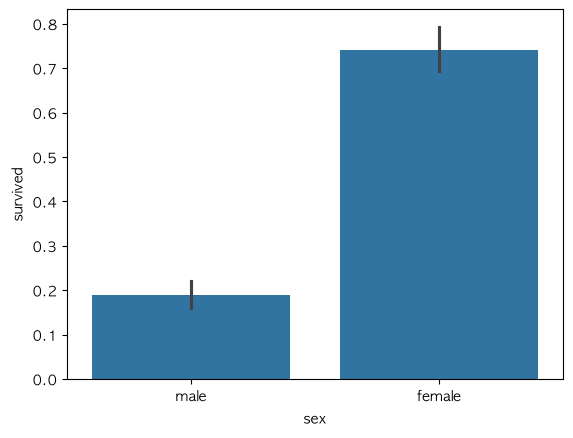

In [19]:
sns.barplot(data=titanic, x='sex', y='survived')

객실 등급별 성별에 따른 생존 확률

- 여성의 경우 일등실, 이등실에 따른 생존 확률의 차이는 크지 않으나, 삼등실의 경우 생존 확률이 상대적으로 많이 떨어짐을 알 수 있다.
- 남성의 경우는 일등실의 생존 확률이 이, 삼등실의 생존 확률보다 월등이 높다.
- 제임스 카메론의 영화인 '타이타닉'에서도 나왔듯이 바다에서 사고가 날 경우 여성과 아이들, 그리고 노약자가 제일 먼저 구조대상이다. 그리고 부자나 유명인이 다음 구조 대상이다. 삼등실에 탄 많은 가난한 이는 타이타닉 호와 운명을 함께 했다.

<Axes: xlabel='pclass', ylabel='survived'>

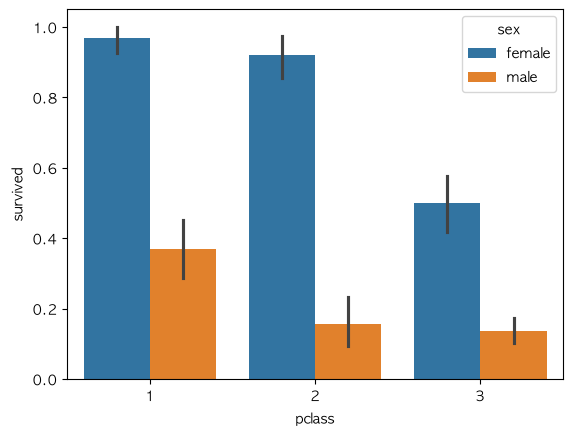

In [20]:
# 선실등급별 남여 생존여부
sns.barplot(data=titanic, x='pclass', y='survived', hue='sex')

In [21]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  891 non-null    str     
 13  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(4)
memory usage: 73.7 KB


In [22]:
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

**⁠LabelEncoder**와 **⁠OrdinalEncoder**는 **사이킷런(Scikit-learn)에서 범주형 데이터를 숫자형으로 바꾸는 도구이**다. 가장 큰 차이는 입력 데이터의 차원(1차원 vs 2차원)과 사용 목적(타겟 변수 vs 독립 변수)이다

**주요 차이점**

- **LabelEncoder (1D)**:
    ◦ 1차원 배열(공식 문서 기준 **y, 즉 타겟 변수 레이블**) 전용이다.
    ◦ 데이터프레임의 **단일 컬럼(Series)** 하나만 넣어서 변환해야  한다.
    ◦ 여러 개 컬럼을 한 번에 처리할 수 없다.
- **OrdinalEncoder (2D)**:
    ◦ 2차원 배열(공식 문서 기준 **X, 즉 독립 변수 피처**) 전용이다.
    ◦ 데이터프레임 전체나 **여러 개 컬럼을 동시에** 숫자로 바꿀 수 있습니다.
- **공통점과 주의할 점**
    - 둘 다 문자를 0부터 시작하는 정수 번호로 바꾼다. 숫자가 커질수록 모델이 크기나 순서(대소 관계)로 오해할 수 있다. 순서가 없는 일반 범주형 데이터에는 원핫인코딩(One-Hot Encoding)이 더 알맞습니다.

### LabelEncoder() 로 인코딩

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic_df1 = titanic.copy()

# 변환할 컬럼 목록(str, category)
label_cols = ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town']

for col in label_cols:
    titanic_df1[col] = le.fit_transform(titanic_df1[col])



In [24]:
titanic_df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    int64  
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     891 non-null    int64  
 8   class        891 non-null    int64  
 9   who          891 non-null    int64  
 10  adult_male   891 non-null    bool   
 11  deck         891 non-null    int64  
 12  embark_town  891 non-null    int64  
 13  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(10)
memory usage: 85.4 KB


In [25]:
titanic_df1[label_cols].head()

,sex,embarked,class,who,deck,embark_town
0,1,3,2,1,7,3
1,0,0,0,2,2,0
2,0,3,2,2,7,3
3,0,3,0,2,2,3
4,1,3,2,1,7,3


In [26]:
print(titanic['sex'].head())
print(titanic_df1['sex'].head())

0      male
1    female
2    female
3    female
4      male
Name: sex, dtype: str
0    1
1    0
2    0
3    0
4    1
Name: sex, dtype: int64


In [27]:
titanic_df1['sex'].value_counts()

sex
1    577
0    314
Name: count, dtype: int64

In [28]:
titanic_df1['deck'].value_counts()

deck
7    688
2     59
1     47
3     33
4     32
0     15
5     13
6      4
Name: count, dtype: int64

### OneHotEncoder(sparse_output=False, handle_unknown='ignore')

| 파라미터                      | 설명                                                                            |
| ------------------------- | ----------------------------------------------------------------------------- |
| `sparse_output=False`     | 반환값을 **희소 행렬(sparse matrix)** 대신 **NumPy 배열**로 반환. <br> → DataFrame으로 변환하기 쉬움 |
| `handle_unknown='ignore'` | 학습 시 보지 못한 **새로운 범주가 등장해도 에러 없이 무시**. <br> → 안정적인 예측 및 인코딩 수행                 |


In [29]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')


titanic_df2 = titanic.copy()


# 변환할 컬럼 목록
ohe_cols = ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town']

ohe_result = pd.DataFrame(index = titanic_df2.index)
print('ohe_result:', ohe_result.head())
print('ohe_result_len:', len(ohe_result))


for col in ohe_cols:
    encoded  = ohe.fit_transform(titanic_df2[[col]])
    # print(encoded)

    col_names = ohe.get_feature_names_out([col])
    # print(col_names)    # ['sex_female' 'sex_male']

    encoded_df = pd.DataFrame(encoded, columns=col_names, index = titanic_df2.index)
    ohe_result = pd.concat([ohe_result, encoded_df], axis=1)
    # print(ohe_result.head())
    # break


ohe_result: Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]
ohe_result_len: 891


In [30]:
print(len(ohe_result.columns))
ohe_result.head()


24


,sex_female,sex_male,embarked_C,embarked_N,embarked_Q,embarked_S,class_First,class_Second,class_Third,who_child,...,deck_C,deck_D,deck_E,deck_F,deck_G,deck_N,embark_town_Cherbourg,embark_town_N,embark_town_Queenstown,embark_town_Southampton
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [31]:
titanic_df2.drop(columns=ohe_cols, inplace=True)

In [32]:
titanic_df2 = pd.concat([titanic_df2, ohe_result], axis=1)

In [33]:
print(titanic_df2.columns)
titanic_df2.head(1)

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male',
       'alone', 'sex_female', 'sex_male', 'embarked_C', 'embarked_N',
       'embarked_Q', 'embarked_S', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton'],
      dtype='str')


,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_female,sex_male,...,deck_C,deck_D,deck_E,deck_F,deck_G,deck_N,embark_town_Cherbourg,embark_town_N,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.25,True,False,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


| 컬럼명           | 타입       | 인코딩 방식        | 설명                      |
| ------------- | -------- | ------------- | ----------------------- |
| `sex`         | str   | OneHotEncoder | 남/여 → 순서 의미 없음          |
| `embarked`    | str   | OneHotEncoder | 탑승 항구 (순서 없음)           |
| `class`       | category | LabelEncoder  | 1등, 2등, 3등 (순서 있음)      |
| `who`         | str   | OneHotEncoder | man/woman/child (순서 없음) |
| `deck`        | category | OneHotEncoder | 갑판 A\~G,N (순서 없음)       |
| `embark_town` | str   | OneHotEncoder | 도시명 (순서 없음)             |
| `adult_male`  | bool     | LabelEncoder  | True/False → 1/0        |
| `alone`       | bool     | LabelEncoder  | True/False → 1/0        |


데이터 전처리를 단계별로 진행할 때 범주형 변수와 연속형 변수를 나누고, 개별적으로 전처리하는 과정을 했다.
sklean-learn에서 제공하는 make_column_transformer와 ColumnTransformer을 이용해서 범주형변수와 연속형 변수를 한번에  전처리를 할 수 있도록 제공해준다.

make_column_transformer를 이용한 인코딩
- make_column_transformer((전처리 객체, 전처리를 적용할 컬럼), (전처리 객체, 전처리를 적용할 컬럼))
- LabelEncoder는 1차원만 처리 가능하므로 make_column_transformer에 직접 쓸 수 없습니다. 대신 **OrdinalEncoder**를 사용한다.

### make_column_transformer

In [34]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

titanic_df3 = titanic.copy()

In [35]:
titanic_df3.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alone'],
      dtype='str')

In [36]:
# 인코딩 컬럼 정의
onehot_cols = ['sex', 'embarked', 'who', 'deck', 'embark_town']
ordinal_cols = ['class', 'adult_male', 'alone']

[아래 소스에서 verbose_feature_names_out=True  # default ]   
encoded_df :Index(['onehotencoder__sex_female', 'onehotencoder__sex_male',
       'onehotencoder__embarked_C', 'onehotencoder__embarked_N',
       'onehotencoder__embarked_Q', 'onehotencoder__embarked_S',
       'onehotencoder__who_child', 'onehotencoder__who_man',
       'onehotencoder__who_woman', 'onehotencoder__deck_A',
       'onehotencoder__deck_B', 'onehotencoder__deck_C',
       'onehotencoder__deck_D', 'onehotencoder__deck_E',
       'onehotencoder__deck_F', 'onehotencoder__deck_G',
       'onehotencoder__deck_N', 'onehotencoder__embark_town_Cherbourg',
       'onehotencoder__embark_town_N', 'onehotencoder__embark_town_Queenstown',
       'onehotencoder__embark_town_Southampton', 'ordinalencoder__class',
       'ordinalencoder__adult_male', 'ordinalencoder__alone',
       'remainder__survived', 'remainder__pclass', 'remainder__age',
       'remainder__sibsp', 'remainder__parch', 'remainder__fare'],
      dtype='str')


[verbose_feature_names_out=False  # 접두사 제거 옵션 ]  
encoded_df :Index(['sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q',
       'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone', 'survived',
       'pclass', 'age', 'sibsp', 'parch', 'fare'],
      dtype='str')

In [37]:
titanic_df3 = titanic.copy()
column_transformer_ignore = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
    (OrdinalEncoder(), ordinal_cols),
    remainder='passthrough',
    verbose_feature_names_out=False  # 접두사 제거 옵션
)

encoded = column_transformer_ignore.fit_transform(titanic_df3)
feature_names = column_transformer_ignore.get_feature_names_out()

encoded_df = pd.DataFrame(encoded, columns=feature_names)
print(f'encoded_df :{encoded_df.columns}')
print(encoded_df.head(1))

encoded_df :Index(['sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q',
       'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone', 'survived',
       'pclass', 'age', 'sibsp', 'parch', 'fare'],
      dtype='str')
   sex_female  sex_male  embarked_C  embarked_N  embarked_Q  embarked_S  \
0         0.0       1.0         0.0         0.0         0.0         1.0   

   who_child  who_man  who_woman  deck_A  ...  embark_town_Southampton  class  \
0        0.0      1.0        0.0     0.0  ...                      1.0    2.0   

   adult_male  alone  survived  pclass   age  sibsp  parch  fare  
0         1.0    0.0       0.0     3.0  22.0    1.0    0.0  7.25  

[1 rows x 30 columns]


ColumnTransformer는 이용한 인코딩
- make_column_transformer와 별칭 지정 유무만 차이가 있고 결과는 동일하게 나온다.
- ColumnTransformer(transformers=[(별칭, 전처리 객체, 전처리를 적용할 컬럼),(별칭, 전처리 객체, 전처리를 적용할 컬럼)],remainder='passthrough')

In [38]:
from sklearn.compose import ColumnTransformer

titanic_df4 = titanic.copy()


In [39]:
titanic_df4.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,N,Southampton,False


In [40]:
target = titanic['survived']
target

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64

In [41]:

titanic_df4 = titanic_df4.iloc[:, 1:]  # titanic_df5['sex'] titanic_df5[['sex', 'embarked', 'who']]

# 2. 인코더 지정
onehot_cols = ['sex', 'embarked', 'who', 'deck', 'embark_town']
ordinal_cols = ['class',  'adult_male', 'alone']

# 3. ColumnTransformer 정의
ct = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
        ('ordinal', OrdinalEncoder(), ordinal_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False  # 컬럼명에 'onehot__', 'ordinal__' 접두사 제거
)

# 4. 변환 실행
encoded_array = ct.fit_transform(titanic_df4)

# 5. 변환된 컬럼명 추출 및 DataFrame 생성
feature_names = ct.get_feature_names_out()
encoded_df = pd.DataFrame(encoded_array, columns=feature_names)

# print(encoded_df.head(1))
print(encoded_df.columns)

Index(['sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q',
       'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone', 'pclass',
       'age', 'sibsp', 'parch', 'fare'],
      dtype='str')


In [42]:
print(encoded_df.columns)

Index(['sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q',
       'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone', 'pclass',
       'age', 'sibsp', 'parch', 'fare'],
      dtype='str')


In [43]:
X_train, X_test, y_train, y_test = train_test_split(encoded_df, target, test_size= 0.25, stratify=target, shuffle=True )
print(f'X_train:', X_train.shape)
print(f'X_test:', X_test.shape)
print(f'y_train:', y_train.shape)
print(f'y_test:', y_test.shape)

print(f'train:{y_train.value_counts()}' )
print(f'test:{y_test.value_counts()}' )

X_train: (668, 29)
X_test: (223, 29)
y_train: (668,)
y_test: (223,)
train:survived
0    412
1    256
Name: count, dtype: int64
test:survived
0    137
1     86
Name: count, dtype: int64


In [44]:
# LogisticRegression 알고리즘
model = LogisticRegression(max_iter=1000)

# 훈련
model.fit(X_train, y_train)

# 테스트
y_pred = model.predict(X_test)


In [45]:
# 혼동행렬
confusion_matrix(y_test,y_pred)

array([[114,  23],
       [ 16,  70]])

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.83      0.85       137
           1       0.75      0.81      0.78        86

    accuracy                           0.83       223
   macro avg       0.81      0.82      0.82       223
weighted avg       0.83      0.83      0.83       223



In [47]:

# 평가지표
print('평가지표')
print(f'Accuracy : {accuracy_score(y_test, y_pred)}')
print(f'Precision : {precision_score(y_test, y_pred)}')
print(f'Recall : {recall_score(y_test, y_pred)}')
print(f'F1 Score : {f1_score(y_test, y_pred)}')

평가지표
Accuracy : 0.8251121076233184
Precision : 0.7526881720430108
Recall : 0.813953488372093
F1 Score : 0.7821229050279329
